# **Melanoma Detection Pipeline – Deep Learning & Medical Imaging Workflow**

El melanoma es uno de los tipos de cáncer cutáneo más agresivos, cuya detección temprana resulta determinante para la supervivencia del paciente. El diagnóstico clínico convencional depende en gran medida de la experiencia del dermatólogo y del análisis visual mediante dermatoscopios, lo que introduce un componente subjetivo y limita la escalabilidad del proceso.

El avance de la **Inteligencia Artificial aplicada a imágenes médicas**, especialmente mediante **Redes Neuronales Convolucionales (CNNs)**, ha permitido desarrollar modelos capaces de aprender patrones visuales sutiles no perceptibles al ojo humano, habilitando sistemas de apoyo a la decisión clínica con potencial de igualar o superar el rendimiento de especialistas humanos en tareas específicas.

**<u>Propósito del Proyecto</u>**

El presente trabajo tiene como propósito **diseñar, entrenar y evaluar un modelo de aprendizaje profundo para la clasificación binaria de lesiones cutáneas** (benignas vs. malignas), a partir de **imágenes dermatoscópicas estandarizadas**. El modelo busca optimizar tanto la **sensibilidad** (minimización de falsos negativos) como el **área bajo la curva ROC (AUC)**, garantizando un equilibrio entre sensibilidad y especificidad.

El proyecto se enmarca dentro de una **pipeline integral de Data Engineering y Machine Learning**, que incluye desde la adquisición y preprocesamiento de datos hasta la evaluación cuantitativa y la interpretación visual de los resultados mediante *explainability*.


> El notebook refleja un proceso completo de investigación aplicada y desarrollo experimental en el ámbito del **Deep Learning para la salud**, documentando cada fase bajo principios de reproducibilidad, trazabilidad y rigor técnico.


## **Vision & Objectives — “Defining the Mission”**

El desafío central consiste en **entrenar un modelo de clasificación binaria** capaz de distinguir entre **lesiones cutáneas benignas y melanomas malignos** utilizando imágenes dermatoscópicas en alta resolución.
Desde una perspectiva de ingeniería de datos y modelado, esto implica:

* Trabajar con datasets heterogéneos, potencialmente desbalanceados.
* Garantizar la calidad y homogeneidad del input visual.
* Optimizar el rendimiento del modelo frente a métricas clínicas críticas.

La naturaleza biomédica del problema exige priorizar la **sensibilidad (recall)** como métrica primaria —dado que los falsos negativos pueden tener consecuencias clínicas graves—, complementada por la **curva ROC y su AUC** como indicador de la capacidad discriminativa global del modelo.

### **Objetivos Clínicos y Analíticos**

**Objetivo Clínico Principal:** Maximizar la capacidad del modelo para identificar correctamente los casos malignos (alta sensibilidad), minimizando la omisión de melanomas reales.

**Objetivos Analíticos Secundarios:**

* Obtener un **AUC ≥ 0.90** en el conjunto de test.
* Mantener un equilibrio entre **precisión y especificidad**, evitando sesgos hacia una sola clase.
* Validar la robustez del modelo mediante técnicas de *cross-validation* y análisis estadístico de desempeño.
* Incorporar mecanismos de **explainability visual** (Grad-CAM, LIME) que aporten transparencia y trazabilidad al diagnóstico automatizado.

### **Estrategia Experimental**

El desarrollo seguirá una estrategia de experimentación iterativa basada en tres componentes esenciales:

1. **Baseline Model:** Implementación de una CNN base (por ejemplo, VGG16 o ResNet preentrenada) que servirá como punto de referencia para la comparación de resultados.
2. **Benchmarking Framework:** Evaluación comparativa de diferentes configuraciones (arquitectura, hiperparámetros, regularización, optimizador, etc.) para establecer un banco de pruebas empírico.
3. **Interpretabilidad Clínica:** Generación de *heatmaps* y mapas de activación que permitan verificar la correlación entre las regiones destacadas por el modelo y las áreas anatómicas de interés clínico.

La combinación de estas fases permitirá alcanzar un pipeline reproducible, escalable y alineado con los estándares de **Data Science en entornos biomédicos**, integrando la rigurosidad del *Data Engineering* con la sensibilidad clínica del *Deep Learning aplicado a la salud*.

## **System Setup — “Building the Foundation”**
Establecer un **entorno reproducible, trazable y auditable** para investigación en visión por computador: control de versiones de dependencias, *seeds* deterministas, estructura canónica de proyecto, configuración centralizada (`CFG`) y registro estándar de ejecuciones (runs, métricas y logs).
> Este bloque garantiza que **dos ejecuciones con los mismos datos y params** produzcan resultados comparables.

In [28]:
from __future__ import annotations
import os, sys, json, time, random, shutil, platform, hashlib, math
from dataclasses import dataclass, asdict
from datetime import datetime
from typing import Dict, Any
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError
from collections import Counter
import pandas as pd

import numpy as np
import tensorflow as tf

plt.style.use("seaborn-v0_8-whitegrid")
colors = plt.get_cmap("Set2")(np.linspace(0, 1, 2))

### **Determinismo básico**
Fijar la semilla global es el primer paso para garantizar que el pipeline sea **científicamente reproducible**. No elimina toda la variabilidad (especialmente en GPU), pero reduce el ruido experimental y permite comparar configuraciones de manera justa.

In [29]:
# Reproducibility: Set random seeds for reproducibility.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

### **Rutas base del proyecto**
En este bloque se **definen las rutas estándar** que estructuran el flujo de trabajo del proyecto con las buenas prácticas de *Data Engineering* y *MLOps Research*.
* El objetivo es garantizar una **organización coherente, trazable y reproducible** de todos los artefactos generados durante la experimentación (modelos, métricas, logs y resultados finales).

Al centralizar las rutas desde el inicio, se asegura que **todos los módulos (entrenamiento, validación, interpretabilidad, etc.) escriban y lean desde ubicaciones controladas**, evitando dispersión de archivos y conflictos de versiones.

In [30]:
# Project Structure. Define canonical directories for results storage.
PROJECT_ROOT = Path(os.getcwd()).parent.resolve()
RESULTS_DIR  = os.path.join(PROJECT_ROOT, "results") # Experiments and derived results.
RUNS_DIR     = os.path.join(RESULTS_DIR, "runs") # Models and training histories.
METRICS_DIR  = os.path.join(RESULTS_DIR, "metrics") # CSV/JSON with aggregated metrics.
LOGS_DIR     = os.path.join(RESULTS_DIR, "logs") # Experiment logs.
FINAL_DIR    = os.path.join(RESULTS_DIR, "final_model") # Final model artifacts.

In [31]:
for d in [RESULTS_DIR, RUNS_DIR, METRICS_DIR, LOGS_DIR, FINAL_DIR]:
    os.makedirs(d, exist_ok=True)

### **Registro maestro de experimentos**
Este bloque implementa un **mecanismo de trazabilidad** centralizada que permite registrar automáticamente cada ejecución del modelo (`run`) en un archivo CSV estructurado. Su propósito es **mantener un historial auditable y reproducible** de todos los experimentos realizados, junto con sus configuraciones e hiperparámetros clave.

El archivo actúa como un **log maestro** —una fuente única de verdad— que consolida metadatos técnicos de cada entrenamiento, facilitando la comparación posterior entre configuraciones, el análisis de resultados y la selección del modelo óptimo.

In [32]:
# Experiment Logging: CSV log to track all experiment runs and parameters.
EXPERIMENTS_LOG = os.path.join(LOGS_DIR, "experiments_log.csv")
if not os.path.exists(EXPERIMENTS_LOG):
    with open(EXPERIMENTS_LOG, "w", encoding="utf-8") as f:
        f.write("ts,run_id,img_size,augment_strength,dropout,base_lr,color_space,extra_channel,notes,seed\n")

In [33]:
# Auxiliary function to append a row to the experiments log with a fixed column order.
def append_experiment_log(row: Dict[str, Any]):
    keys = ["ts","run_id","img_size","augment_strength","dropout","base_lr","color_space","extra_channel","notes","seed"]
    line = ",".join(str(row.get(k, "")) for k in keys)
    with open(EXPERIMENTS_LOG, "a", encoding="utf-8") as f:
        f.write(line + "\n")

### **Config global: Dataclass**
Este bloque define una clase de configuración central (`CFG`) utilizando el decorador `@dataclass`, que actúa como **fuente única de verdad** para todos los parámetros de ejecución del proyecto.
* El objetivo es **unificar y documentar explícitamente** los hiperparámetros, rutas y ajustes experimentales en un solo objeto inmutable y serializable.

En proyectos de *Machine Learning* complejos, la configuración de entrenamiento suele dispersarse entre celdas, scripts o argumentos de función. `CFG` evita ese problema creando una **estructura de configuración declarativa**, clara, versionable y fácil de exportar junto con los resultados de cada experimento.
* Cada campo de la clase representa un **parámetro técnico esencial** del pipeline, y su instancia (`CFG_GLOBAL`) sirve como **configuración base** sobre la cual se derivan clones o variantes para experimentos específicos.

> `CFG` actúa como el **núcleo declarativo** del experimento: un contenedor estructurado que centraliza todos los parámetros críticos del pipeline.
> Su diseño asegura que cada entrenamiento sea **trazable, reproducible y auto-documentado**, manteniendo estándares de ingeniería propios de proyectos profesionales de *Deep Learning Research*.


In [34]:
@dataclass
class CFG:
    # Input data parameters.
    img_size: int = 256 # Image size (height and width).
    channels: int = 3 # Number of image channels (3 for RGB; 4 for RGB + H from HSV).
    color_space: str = "rgb" # Color space: "rgb", "hsv".
    extra_channel: str = "" # Extra channel to add: "hue", "saturation", "value", or "" for none.
    # Model training hyperparameters.
    batch_size: int = 32
    epochs: int = 30
    base_lr: float = 1e-3
    dropout: float = 0.4
    augment_strength: str = "light"
    early_stopping_patience: int = 6
    # Seed for reproducibility.
    seed: int = SEED
    # Directories: Data paths.
    data_train_dir: str = "../data/train"
    data_test_dir: str  = "../data/test"
    data_val_dir: str = "../data/val"

    def to_json(self) -> str:
        '''
        Allow saving the configuration alongside the trained model or within the run directory,
        ensuring exact traceability of the experimental context.
        '''
        return json.dumps(asdict(self), indent=2, ensure_ascii=False)

In [35]:
CFG_GLOBAL = CFG() # Global default configuration instance.

### **Gestor de ejecuciones: Runs**
Este bloque implementa el **sistema de gestión de ejecuciones o *Run Manager***, encargado de crear, identificar y estructurar automáticamente cada experimento de entrenamiento realizado dentro del proyecto.

En proyectos de *Machine Learning* orientados a investigación y validación sistemática, mantener un registro claro y organizado de cada ejecución es **imprescindible para la reproducibilidad, trazabilidad y análisis comparativo de resultados**.

El *Run Manager* automatiza ese proceso, estandarizando la forma en que se generan identificadores únicos, se estructuran carpetas y se persisten configuraciones y artefactos.

In [36]:
def _short_hash(s: str, n: int = 6) -> str: # Generate a short hash of length n from string s.
    return hashlib.sha1(s.encode("utf-8")).hexdigest()[:n]

In [37]:
def create_run_id(cfg: CFG, notes: str = "") -> str: # Generate unique run ID.
    '''
    Create a unique run identifier based on the current timestamp and a hash of key configuration parameters.
    This ensures that each experiment can be distinctly identified and traced back to its configuration.
    '''
    ts = datetime.now().strftime("%Y%m%d-%H%M%S")
    sig = f"{cfg.img_size}_{cfg.augment_strength}_{cfg.dropout}_{cfg.base_lr}_{cfg.color_space}_{cfg.extra_channel}"
    return f"{ts}_exp-{_short_hash(sig)}"

In [38]:
def prepare_run_folders(run_id: str) -> Dict[str, str]:
    '''
    Create and return a dictionary with paths for the given run ID.
    Ensures all necessary directories exist for storing models, artifacts, logs, and configuration.
    '''
    run_dir = os.path.join(RUNS_DIR, run_id)
    paths = {
        "run_dir": run_dir,
        "models_dir": os.path.join(run_dir, "models"),
        "arts_dir": os.path.join(run_dir, "artifacts"),
        "history_path": os.path.join(run_dir, "history.csv"),
        "best_model_path": os.path.join(run_dir, "best_model.keras"),
        "cfg_path": os.path.join(run_dir, "cfg.json"),
        "notes_path": os.path.join(run_dir, "notes.txt"),
        "stdout_path": os.path.join(run_dir, "stdout.txt"),
    }
    for p in paths.values():
        parent = os.path.dirname(p)
        os.makedirs(parent, exist_ok=True)
    return paths

In [39]:
def persist_cfg(cfg: CFG, cfg_path: str, notes: str = ""):
    '''
    Save the configuration to a JSON file and optionally save notes to a text file.
    '''
    with open(cfg_path, "w", encoding="utf-8") as f:
        f.write(cfg.to_json())
    if notes:
        with open(os.path.join(os.path.dirname(cfg_path), "notes.txt"), "w", encoding="utf-8") as f:
            f.write(notes.strip() + "\n")

Todos estos bloques establecen el **núcleo operativo del control experimental** del proyecto: un sistema de identificación, persistencia y documentación automática de cada ejecución.
En términos de ingeniería, es el equivalente a un *mini MLOps* tracking system interno, diseñado para proyectos de investigación donde la precisión, la organización y la trazabilidad son críticas.

### **Resumen del entorno: Trazabilidad**
Este bloque imprime un **resumen de entorno de ejecución** que permite validar las condiciones técnicas bajo las cuales se desarrolla el experimento.
La trazabilidad del entorno es fundamental para g**arantizar reproducibilidad científica y consistencia** entre ejecuciones, especialmente en contextos donde los resultados pueden verse afectados por versiones de librerías o diferencias de hardware.

In [40]:
def print_env_summary():
    print("== System summary ==")
    print("Python:", sys.version.split()[0], "| TensorFlow:", tf.__version__)
    print("Platform:", platform.platform())
    print("Results dir:", RESULTS_DIR)
    print("Seed:", SEED)

print_env_summary()

== System summary ==
Python: 3.10.7 | TensorFlow: 2.10.0
Platform: Windows-10-10.0.19045-SP0
Results dir: C:\Users\mgonzgarc\Documents\GitHub\cancer-ai-usecase\results
Seed: 42


En esta sección se realiza la **inspección y configuración del entorno de cómputo acelerado (GPU)**, un paso esencial para garantizar el rendimiento óptimo y la reproducibilidad del entrenamiento de modelos de *Deep Learning*.

Las GPU (Unidades de Procesamiento Gráfico) son componentes críticos en flujos de trabajo con **redes neuronales convolucionales (CNNs)**, ya que permiten procesar grandes volúmenes de imágenes en paralelo, reduciendo drásticamente los tiempos de entrenamiento.

In [41]:
print("== GPU detection ==")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        print("Available GPU:", gpu)
    try:
        # Enable memory growth (do not allocate all memory at once)
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        logical_gpus = tf.config.list_logical_devices('GPU')
        print(f'[OK] {len(gpus)} Physical GPU(s), {len(logical_gpus)} Logical GPU(s) detected.')
    except RuntimeError as e:
        print("[WARN] Could not modify GPU configuration:", e)
else:
    print("[INFO] No GPUs detected. TensorFlow will use CPU.")

== GPU detection ==
Available GPU: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
[OK] 1 Physical GPU(s), 1 Logical GPU(s) detected.


Este bloque realiza un **ensayo de infraestructura** —una simulación completa del flujo de inicialización y registro del sistema experimental. Su función es garantizar que el entorno, las rutas y los mecanismos de trazabilidad estén perfectamente configurados antes de proceder a fases de entrenamiento y validación del modelo.

In [42]:
_notes = "Dry-run de setup; sin entrenamiento."
run_id = create_run_id(CFG_GLOBAL, notes=_notes)
paths = prepare_run_folders(run_id)
persist_cfg(CFG_GLOBAL, paths["cfg_path"], notes=_notes)
append_experiment_log({
    "ts": datetime.now().isoformat(timespec="seconds"),
    "run_id": run_id,
    "img_size": CFG_GLOBAL.img_size,
    "augment_strength": CFG_GLOBAL.augment_strength,
    "dropout": CFG_GLOBAL.dropout,
    "base_lr": CFG_GLOBAL.base_lr,
    "color_space": CFG_GLOBAL.color_space,
    "extra_channel": CFG_GLOBAL.extra_channel,
    "notes": "setup-ok",
    "seed": CFG_GLOBAL.seed,
})

In [43]:
print(f"[OK] Initial structure created at: {paths['run_dir']}")

[OK] Initial structure created at: C:\Users\mgonzgarc\Documents\GitHub\cancer-ai-usecase\results\runs\20251010-151320_exp-114dbe


## **Data Ingestion — “Feeding the Brain”**
En esta sección se desarrolla la **fase de ingesta y validación de datos**, donde el sistema recibe las imágenes dermatoscópicas que alimentarán el modelo de *Deep Learning*.
Esta etapa constituye el **punto de entrada del pipeline** y tiene como objetivo garantizar que los datos suministrados al modelo sean **coherentes, balanceados y trazables**, sentando las bases de un entrenamiento fiable y científicamente reproducible.

El éxito de cualquier red neuronal depende directamente de la **calidad, representatividad y control del conjunto de datos**. En un contexto clínico como la detección de melanomas, los datos deben cumplir condiciones estrictas: **imágenes bien etiquetadas, resolución uniforme y proporciones adecuadas** entre clases benignas y malignas.

> **Importancia para el flujo clínico-analítico**
> Una ingesta de datos rigurosa **garantiza la validez científica del modelo**. Al validar desde el inicio el equilibrio entre clases, se previene un sesgo diagnóstico que podría traducirse en **falsos negativos clínicamente críticos**.

In [44]:
AUTOTUNE = tf.data.AUTOTUNE # Enable data prefetching for performance optimization.

Esta función constituye el **punto de partida de la fase de ingesta de datos:** se encarga de **detectar automáticamente** las clases disponibles dentro del directorio base (`train/` o `test/`), asumiendo la estructura estándar de datasets por carpetas.

In [45]:
def _detect_class_dirs(base_dir: str):
    """
    Detects class directories within the base directory. (e.g., Benign / Malignant).
    Returns an alphabetically sorted list for stability.
    """
    p = Path(base_dir)
    class_dirs = [d.name for d in p.iterdir() if d.is_dir()]
    if not class_dirs:
        raise ValueError(f"No class subdirectories found in {base_dir}")
    return sorted(class_dirs)

Esta función realiza un análisis exploratorio automático del dataset de imágenes, verificando: **qué clases existen, cuántas imágenes hay por clase, y si el dataset está balanceado entre clases y splits (train y test).**
* El objetivo es **asegurar la integridad de los datos** antes del preprocesamiento o entrenamiento del modelo.

> En proyectos clínicos o de visión por computador, este control es fundamental: un desequilibrio fuerte entre clases (por ejemplo, 90% benignas y 10% malignas) puede sesgar el modelo y deteriorar la sensibilidad.

In [46]:
def summarize_counts(train_dir: str, test_dir: str, val_dir: str):
    """
    Count images per class in train and test using glob.
    """
    def count_in_split(split_dir: str, classes: list[str]) -> dict:
        counts = {}
        for c in classes:
            counts[c] = len(list(Path(split_dir, c).glob("**/*.*")))
        counts["TOTAL"] = sum(counts.values())
        return counts

    classes = _detect_class_dirs(train_dir)
    train_counts = count_in_split(train_dir, classes)
    test_counts  = count_in_split(test_dir, classes)
    val_counts = count_in_split(val_dir, classes)
    return classes, train_counts, test_counts, val_counts

In [47]:
def build_datasets(cfg: CFG):
    """
    Load datasets from folders:
        - train_dir: split into train/val with validation_split (stratified).
        - test_dir: final evaluation only; no mixing or shuffling.
    """
    img_size = (cfg.img_size, cfg.img_size) # (height, width)
    batch    = cfg.batch_size # Batch size

    # Detect classes and summarize counts
    classes, train_counts, test_counts, val_counts = summarize_counts(cfg.data_train_dir, cfg.data_test_dir, cfg.data_val_dir)
    print("Detected classes:", classes)
    print("Train counts:", train_counts)
    print("Test  counts:", test_counts)
    print("Val   counts:", val_counts)

    # Save dataset summary
    ds_summary = {
        "classes": classes,
        "train_counts": train_counts,
        "test_counts": test_counts,
        "val_counts": val_counts,
        "img_size": cfg.img_size,
        "batch_size": cfg.batch_size,
        "seed": cfg.seed,
    }
    os.makedirs(METRICS_DIR, exist_ok=True)
    with open(os.path.join(METRICS_DIR, "dataset_summary.json"), "w", encoding="utf-8") as f:
        json.dump(ds_summary, f, indent=2, ensure_ascii=False)

    # Load train and val datasets from train_dir
    train_ds = tf.keras.utils.image_dataset_from_directory(
        cfg.data_train_dir,
        labels="inferred",                 # Labels from directory structure
        label_mode="categorical",          # For AUC/Recall metrics by class
        class_names=classes,               # Ensure consistent class order
        seed=cfg.seed,
        image_size=img_size,
        batch_size=batch,
        shuffle=True,                      # Training: shuffle for better generalization
    )

    val_ds = tf.keras.utils.image_dataset_from_directory(
        cfg.data_val_dir,
        labels="inferred",                 # Labels from directory structure
        label_mode="categorical",          # For AUC/Recall metrics by class
        class_names=classes,               # Ensure consistent class order
        image_size=img_size,
        batch_size=batch,
        shuffle=False,                     # Validation: stable order
    )

    # Test is loaded separately, without mixing
    test_ds = tf.keras.utils.image_dataset_from_directory(
        cfg.data_test_dir,
        labels="inferred",
        label_mode="categorical",
        class_names=classes,
        image_size=img_size,
        batch_size=batch,
        shuffle=False,
    )

    # Optimize the input pipeline
    train_ds = train_ds.prefetch(AUTOTUNE)
    val_ds   = val_ds.cache().prefetch(AUTOTUNE)
    test_ds  = test_ds.cache().prefetch(AUTOTUNE)

    # Show a sample batch (shape and classes)
    sample_images, sample_labels = next(iter(train_ds.take(1)))
    print("Sample batch images shape:", sample_images.shape, "| labels shape:", sample_labels.shape)

    return train_ds, val_ds, test_ds, classes

In [48]:
train_ds, val_ds, test_ds, CLASS_NAMES = build_datasets(CFG_GLOBAL)
print("[OK] Datasets loaded: train/val/test")

Detected classes: ['Benign', 'Malignant']
Train counts: {'Benign': 6289, 'Malignant': 5590, 'TOTAL': 11879}
Test  counts: {'Benign': 1000, 'Malignant': 1000, 'TOTAL': 2000}
Val   counts: {'Benign': 11, 'Malignant': 12, 'TOTAL': 23}
Found 11879 files belonging to 2 classes.
Found 23 files belonging to 2 classes.
Found 2000 files belonging to 2 classes.
Sample batch images shape: (32, 256, 256, 3) | labels shape: (32, 2)
[OK] Datasets loaded: train/val/test


### **Data EDA Utils — “Trust but Verify”**
El análisis exploratorio de datos (EDA) constituye el **primer control de calidad del dataset** y el punto de partida para cualquier modelado fiable.

Antes de aplicar técnicas de *preprocessing* o *data augmentation*, es imprescindible comprender **cómo son las imágenes reales, cuál es su distribución cromática y qué sesgos o irregularidades podrían afectar al entrenamiento** del modelo.

En este bloque se realiza una **auditoría sistemática** del conjunto de imágenes dermatoscópicas, combinando análisis cuantitativo y visual para verificar la integridad y consistencia del dataset.

In [49]:
classes, train_counts, test_counts, val_counts = summarize_counts(CFG_GLOBAL.data_train_dir, CFG_GLOBAL.data_test_dir, CFG_GLOBAL.data_val_dir)

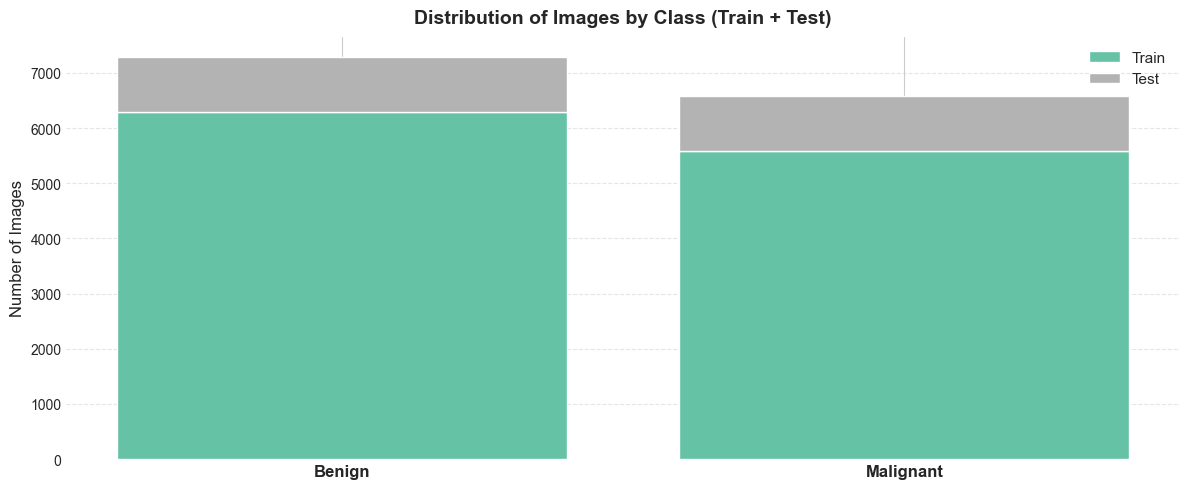

In [50]:
train_color, test_color = colors[0], colors[1]

plt.figure(figsize=(12, 5))
x = np.arange(len(classes))
plt.bar(x, [train_counts[c] for c in classes], color=train_color, edgecolor="white", linewidth=1,
        label="Train",)
plt.bar(x, [test_counts[c] for c in classes], bottom=[train_counts[c] for c in classes], color=test_color,
    edgecolor="white", linewidth=1,label="Test",)
plt.xticks(x, classes, fontsize=12, fontweight="bold")
plt.ylabel("Number of Images", fontsize=12)
plt.title("Distribution of Images by Class (Train + Test)", fontsize=14, fontweight="bold", pad=10)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.box(False)
plt.legend(frameon=False, fontsize=11, loc="upper right")
plt.tight_layout()
plt.show()

In [51]:
num_batches = 4 # Number of batches to process for stats
acc_mean = []
acc_std  = []
count = 0

for bx, _ in train_ds.take(num_batches):
    bx = bx.numpy().astype("float32")
    # Si vienen en 0..255, normalizamos a 0..1 para que sea comparable
    if bx.max() > 1.5:
        bx = bx / 255.0
    # media y std por canal
    acc_mean.append(bx.mean(axis=(0,1,2)))
    acc_std.append(bx.std(axis=(0,1,2)))
    count += 1

mean_c = np.mean(np.stack(acc_mean, axis=0), axis=0)
std_c  = np.mean(np.stack(acc_std,  axis=0), axis=0)
print("Channels:", CLASS_NAMES, " (only for labels; image channels are RGB)")
print("Mean per channel (approx, 0..1):", mean_c)
print("Std per channel (approx, 0..1):", std_c)

# JSON output
with open(os.path.join(METRICS_DIR, "eda_channel_stats.json"), "w", encoding="utf-8") as f:
    json.dump({"mean": mean_c.tolist(), "std": std_c.tolist()}, f, indent=2)

Channels: ['Benign', 'Malignant']  (only for labels; image channels are RGB)
Mean per channel (approx, 0..1): [0.70437306 0.5446192  0.52500474]
Std per channel (approx, 0..1): [0.23380649 0.22291933 0.23541264]


Estas cifras muestran que **el conjunto de imágenes presenta una dominancia moderada del canal rojo**, típica de tejidos cutáneos bajo iluminación natural. El canal verde aporta una contribución intermedia, y el azul es más bajo, indicando una paleta cálida con poca componente fría —característica esperada en fotografías clínicas de piel humana.

**Implicaciones para el modelado**
1. **Distribución de color no uniforme:** El predominio del canal R frente a G/B sugiere que el modelo puede desarrollar un **sesgo hacia tonos rojizos**.
    * En contextos clínicos, este sesgo puede interferir con la detección de lesiones más pálidas, azuladas o con reflejos especulares.

2. **Homogeneidad cromática moderada (σ ≈ 0.2):** La baja dispersión entre imágenes indica que la mayoría de las muestras comparten condiciones similares de iluminación y captura.
    * Esto es positivo para entrenamiento, pero limita la capacidad del modelo de generalizar ante variaciones reales de color (distintas cámaras o clínicas).

3. **Riesgo de sobreajuste cromático:** Un modelo entrenado solo en RGB puede aprender correlaciones espurias entre el tono cutáneo y la etiqueta (por ejemplo, confundir piel más rojiza con malignidad).

> **El análisis apoya la decisión experimental de incorporar espacios de color alternativos (HSV, LAB) y canales híbridos (RGB+H / RGB+S / RGB+V),**

In [52]:
def show_random_grid_from_dataset(ds, class_names, title="Dataset Samples", max_images=24, seed=None):
    # Remix the dataset to get random images
    if seed is not None:
        tf.random.set_seed(seed)
    ds_shuffled = ds.shuffle(buffer_size=1000, seed=seed, reshuffle_each_iteration=True)

    # Take the first batches after shuffling
    xs, ys = [], []
    collected = 0
    for batch_x, batch_y in ds_shuffled.take(2):
        xs.append(batch_x.numpy())
        ys.append(batch_y.numpy())
        collected += batch_x.shape[0]
        if collected >= max_images:
            break

    X = np.concatenate(xs, axis=0)[:max_images]
    Y = np.concatenate(ys, axis=0)[:max_images]

    # Define grid size
    n = X.shape[0]
    cols = 6
    rows = int(np.ceil(n / cols))

    plt.figure(figsize=(cols * 2.3, rows * 2.3))
    for i in range(n):
        ax = plt.subplot(rows, cols, i + 1)
        img = X[i]
        if img.max() <= 1.0:  # If normalized, rescale
            img = (img * 255).astype("uint8")
        else:
            img = img.astype("uint8")
        ax.imshow(img)
        cls = class_names[int(np.argmax(Y[i]))]
        ax.set_title(cls, fontsize=9, fontweight="bold")
        ax.axis("off")

    plt.suptitle(title, fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

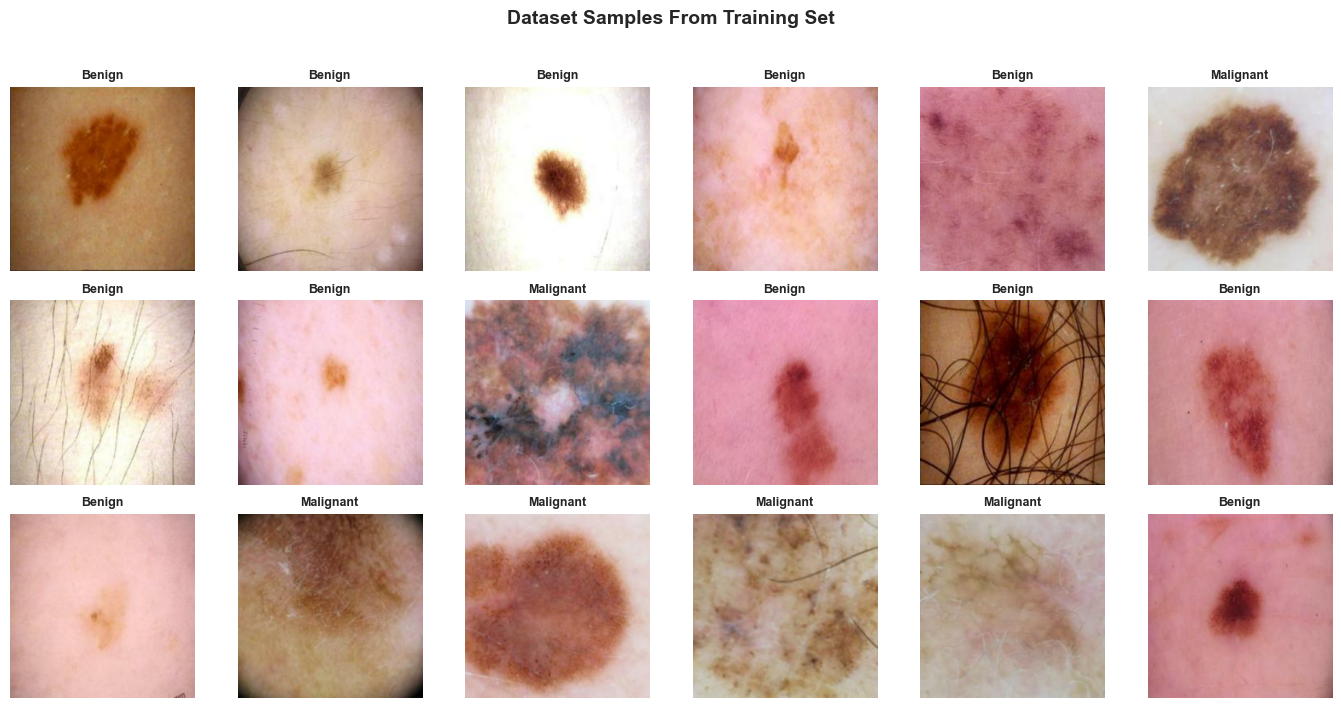

In [53]:
show_random_grid_from_dataset(train_ds, CLASS_NAMES, "Dataset Samples From Training Set", max_images=18)

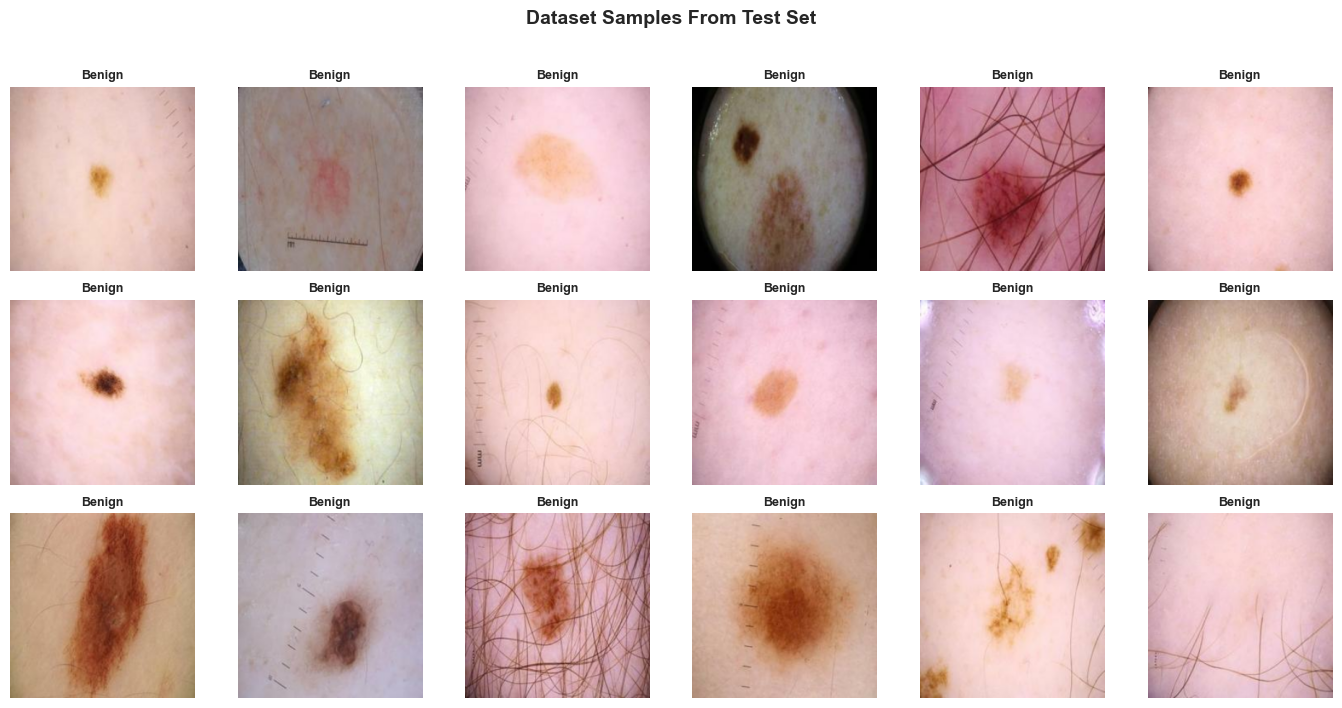

In [54]:
show_random_grid_from_dataset(test_ds, CLASS_NAMES, "Dataset Samples From Test Set", max_images=18)

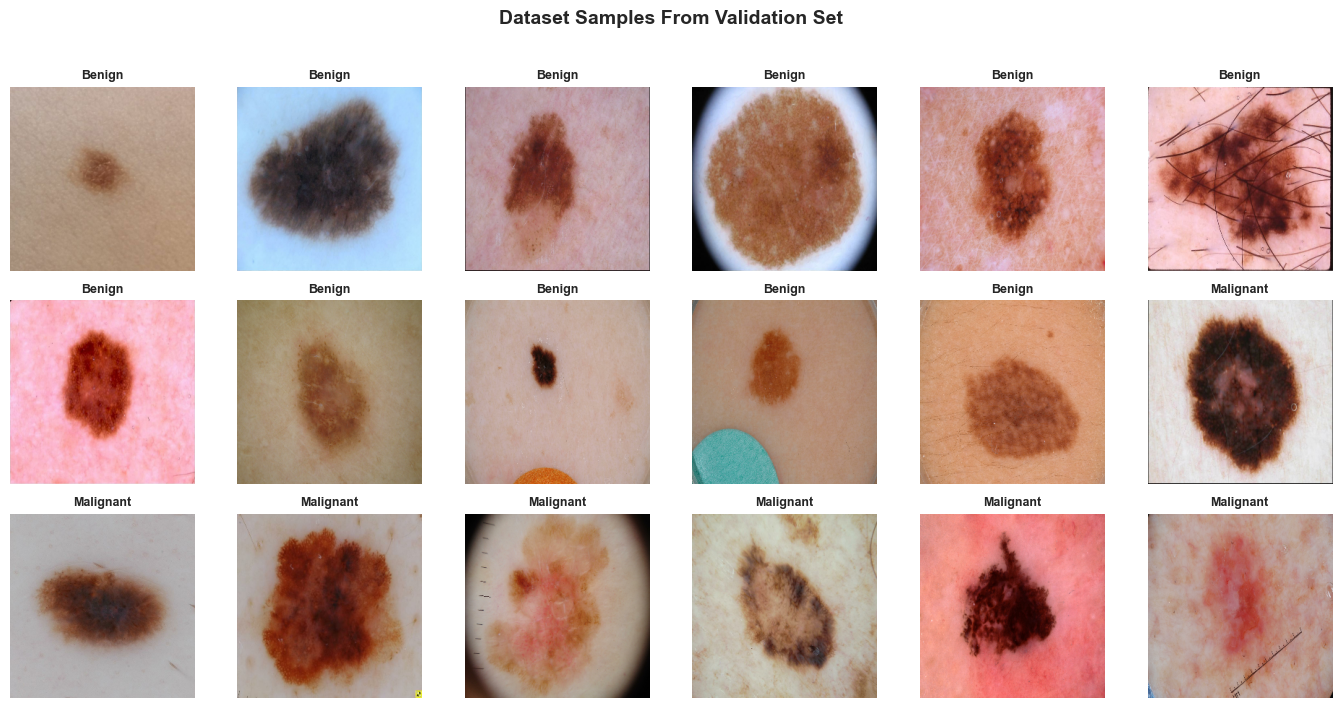

In [55]:
show_random_grid_from_dataset(val_ds, CLASS_NAMES, "Dataset Samples From Validation Set", max_images=18)